<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 3 — Logistic Regression &amp; Classification Metrics</h1>
<h3 style="text-align:center; color:#BE185D;">Sigmoid, Confusion Matrices, Precision/Recall/F1 &amp; AUC-ROC</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. From Regression to Classification</a></li>
<li><a href="#section2">2. Why Accuracy Alone Is Misleading</a></li>
<li><a href="#section3">3. The Confusion Matrix</a></li>
<li><a href="#section4">4. Precision, Recall &amp; F1</a></li>
<li><a href="#section5">5. AUC-ROC</a></li>
<li><a href="#section6">6. Common Mistakes to Avoid</a></li>
<li><a href="#section7">7. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section8">8. Hands-On Lab — Building a Classifier</a></li>
<li><a href="#section9">9. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section10">10. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Yesterday we predicted a <b>number</b> (house price) with Linear Regression. Today we predict a <b>category</b> instead — will a passenger survive or not? Same Scikit-learn toolbox, plus a few new imports for classification metrics.
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 2.3.3
NumPy version       : 2.3.5
Scikit-learn version: 1.7.2


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. From Regression to Classification</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Same idea, different question</h3>
Despite its name, <b>logistic regression</b> is a <b>classification</b> model — it predicts a <b>category</b> (like <i>yes/no</i>), not a plain number. It starts with the exact same weighted sum as linear regression from yesterday:

<p style="text-align:center; font-weight:bold;">weighted_sum = (feature₁ × weight₁) + (feature₂ × weight₂) + ... + bias</p>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 Squashing the number into a probability</h3>
A weighted sum can be any number — negative, huge, tiny. To turn it into something we can call a "probability of survival," logistic regression passes it through the <b>sigmoid function</b>, which squashes any number into a value between <b>0</b> and <b>1</b>.

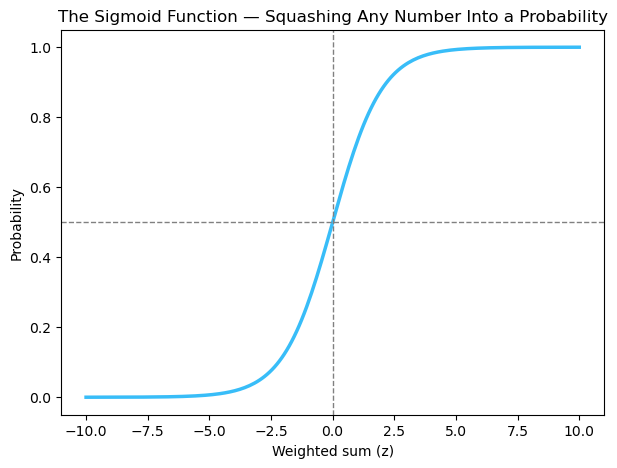

In [6]:
# A tiny intuition-builder: what the sigmoid function looks like
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
probabilities = sigmoid(z_values)

plt.figure(figsize=(7, 5))
plt.plot(z_values, probabilities, color="#38BDF8", linewidth=2.5)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("The Sigmoid Function — Squashing Any Number Into a Probability")
plt.xlabel("Weighted sum (z)")
plt.ylabel("Probability")
plt.show()

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> If the sigmoid output is above a <b>threshold</b> (usually 0.5), the model predicts the <b>positive class</b> (e.g. "survived"). Below the threshold, it predicts the <b>negative class</b> ("did not survive"). The threshold is a choice, not a law of nature — we'll come back to that.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.3 Training and predicting with Scikit-learn — same four-step pattern</h3>


In [7]:
from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(max_iter=1000)   # 1. Instantiate
# model.fit(X_train, y_train)                 # 2. Fit
# predictions = model.predict(X_test)          # 3. Predict the class (0 or 1)
# probabilities = model.predict_proba(X_test)  # 3b. Predict the probability of each class

print("We will run this for real in Section 8 (Hands-On Lab) using an actual dataset.")

We will run this for real in Section 8 (Hands-On Lab) using an actual dataset.


<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Why Accuracy Alone Is Misleading</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 The obvious metric that hides the truth</h3>
<b>Accuracy</b> is the fraction of predictions the model got right. It sounds like the natural way to grade a classifier — but on <b>imbalanced data</b> (where one class is much more common than the other) it can be dangerously misleading.

In [8]:
# A worked example: imagine 100 patients, only 5 of whom actually have a rare disease
total_patients = 100
actual_cases = 5

# A "lazy" model that always predicts "no disease" for everyone
lazy_model_accuracy = (total_patients - actual_cases) / total_patients
print(f"Lazy model accuracy: {lazy_model_accuracy:.0%}")
print("...yet it never once catches an actual case. Accuracy alone hid a completely useless model.")

Lazy model accuracy: 95%
...yet it never once catches an actual case. Accuracy alone hid a completely useless model.


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <b>Rule of thumb:</b> whenever one class is much rarer than the other (fraud, disease, churn, defects), do not trust accuracy on its own. Always look at the metrics in Sections 3–5 as well.
</div>


<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. The Confusion Matrix</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 The foundation of every classification metric</h3>
The <b>confusion matrix</b> breaks predictions into four categories by comparing what the model <b>predicted</b> against what <b>actually</b> happened:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;"></th><th style="padding:8px; text-align:left;">Predicted Positive</th><th style="padding:8px; text-align:left;">Predicted Negative</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;"><b>Actual Positive</b></td><td style="padding:8px; border-top:1px solid #eee;">True Positive (TP) — correctly caught</td><td style="padding:8px; border-top:1px solid #eee;">False Negative (FN) — missed</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;"><b>Actual Negative</b></td><td style="padding:8px; border-top:1px solid #eee;">False Positive (FP) — false alarm</td><td style="padding:8px; border-top:1px solid #eee;">True Negative (TN) — correctly cleared</td></tr>
</table>
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 Reading it in Scikit-learn</h3>


In [9]:
from sklearn.metrics import confusion_matrix

# cm = confusion_matrix(y_test, predictions)
# print(cm)
#
# The matrix is read as:
# [[TN, FP],
#  [FN, TP]]
print("We will compute a real confusion matrix in Section 8.")

We will compute a real confusion matrix in Section 8.


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> A quick way to picture it: <b>TP</b> and <b>TN</b> are the model being right. <b>FP</b> is a "false alarm" (predicted positive, was actually negative). <b>FN</b> is a "miss" (predicted negative, was actually positive). Which mistake is worse depends entirely on the problem.
</div>


<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. Precision, Recall &amp; F1</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 Three numbers built from the confusion matrix</h3>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;">Metric</th><th style="padding:8px; text-align:left;">Formula</th><th style="padding:8px; text-align:left;">Answers the Question</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;"><b>Precision</b></td><td style="padding:8px; border-top:1px solid #eee;">TP / (TP + FP)</td><td style="padding:8px; border-top:1px solid #eee;">Of everything I predicted positive, how much was actually right?</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;"><b>Recall</b></td><td style="padding:8px; border-top:1px solid #eee;">TP / (TP + FN)</td><td style="padding:8px; border-top:1px solid #eee;">Of all the actual positives, how many did I catch?</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;"><b>F1-score</b></td><td style="padding:8px; border-top:1px solid #eee;">harmonic mean of Precision &amp; Recall</td><td style="padding:8px; border-top:1px solid #eee;">A single balanced score when you need both</td></tr>
</table>
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 The trade-off — and why it depends on the problem</h3>
Precision and recall usually pull in opposite directions, and <b>which one matters more is a real decision</b>, not a formula:
<ul>
<li><b>Disease screening:</b> missing a real case (a False Negative) can be life-threatening, so <b>recall</b> matters most — catch every possible case, even with some false alarms.</li>
<li><b>Spam filter:</b> blocking a real, important email (a False Positive) is very annoying, so <b>precision</b> matters most — only flag an email as spam when very confident.</li>
</ul>

In [10]:
from sklearn.metrics import classification_report

# print(classification_report(y_test, predictions))
print("classification_report() prints precision, recall, F1, and support for every class at once.")

classification_report() prints precision, recall, F1, and support for every class at once.


<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> <code>classification_report()</code> is usually the fastest way to see all three metrics — for both classes — in one readable table. Always read it alongside the confusion matrix, not instead of it.
</div>


<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. AUC-ROC</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 Comparing classifiers without picking one threshold</h3>
Precision, recall, and F1 all depend on the <b>0.5 threshold</b> we picked. The <b>ROC curve</b> plots the trade-off between catching positives (<i>true positive rate</i>) and raising false alarms (<i>false positive rate</i>) across <b>every possible threshold</b>, not just one.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">5.2 AUC — one number that summarizes the whole curve</h3>
The <b>AUC (Area Under the Curve)</b> condenses the ROC curve into a single score:
<ul>
<li><b>1.0</b> — a perfect classifier</li>
<li><b>0.5</b> — no better than random guessing (a flat diagonal line)</li>
<li><b>Below 0.5</b> — worse than random (a sign something is likely wrong with the setup)</li>
</ul>
AUC-ROC is the standard way to compare classifiers <b>independently</b> of any single threshold choice.

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

# auc_score = roc_auc_score(y_test, probabilities[:, 1])
# fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])
print("We will plot a real ROC curve with its AUC score in Section 8.")

We will plot a real ROC curve with its AUC score in Section 8.


<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <ul>
<li><b>Trusting accuracy on imbalanced data</b> — always check precision, recall, and F1 too (Section 2).</li>
<li><b>Ignoring the confusion matrix</b> — a single accuracy number hides <i>which kind</i> of mistake the model is making.</li>
<li><b>Assuming 0.5 is always the right threshold</b> — for recall-critical problems (like disease screening) it is often lowered on purpose.</li>
<li><b>Using <code>.predict()</code> when you need probabilities</b> — use <code>.predict_proba()</code> for AUC-ROC and for adjusting the threshold.</li>
<li><b>Evaluating on the training set</b> — as always, only ever score the model on the held-out test set.</li>
</ul>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Quick Reference</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Import the model</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.linear_model import LogisticRegression</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Create &amp; train</td><td style="padding:8px; border-top:1px solid #eee;"><code>model = LogisticRegression(max_iter=1000)</code><br><code>model.fit(X_train, y_train)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Predict classes</td><td style="padding:8px; border-top:1px solid #eee;"><code>predictions = model.predict(X_test)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Predict probabilities</td><td style="padding:8px; border-top:1px solid #eee;"><code>probabilities = model.predict_proba(X_test)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Confusion matrix</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.metrics import confusion_matrix</code><br><code>confusion_matrix(y_test, predictions)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Precision / Recall / F1</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.metrics import classification_report</code><br><code>classification_report(y_test, predictions)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">AUC-ROC score</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.metrics import roc_auc_score</code><br><code>roc_auc_score(y_test, probabilities[:, 1])</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">ROC curve points</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.metrics import roc_curve</code><br><code>roc_curve(y_test, probabilities[:, 1])</code></td></tr>
</table>
</div>


<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Hands-On Lab — Building a Classifier</h2>
<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Train, evaluate, and interpret a complete logistic regression classifier on a real dataset — <b>Titanic passenger data</b> — predicting whether a passenger survived.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">8.0 Loading the dataset</h3>
We will use <code>train_and_test2.csv</code>, a cleaned Titanic-style dataset. Each row is a passenger; the target column <code>2urvived</code> is <b>1</b> if the passenger survived and <b>0</b> if they did not — a classic imbalanced-classification style problem.

In [12]:
titanic = pd.read_csv("train_and_test2.csv")

# Rename the awkwardly-named target column for readability
titanic = titanic.rename(columns={"2urvived": "Survived"})

print("Shape:", titanic.shape)
titanic.head()

Shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,Survived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [13]:
# Quick look at class balance -- is this an imbalanced problem?
print(titanic["Survived"].value_counts())
print()
print("Survival rate:", round(titanic["Survived"].mean() * 100, 1), "%")

Survived
0    967
1    342
Name: count, dtype: int64

Survival rate: 26.1 %


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> The dataset already has categorical columns like <code>Sex</code> and <code>Embarked</code> encoded as numbers, and no missing values in the columns we will use — so we can go straight to picking features without extra cleanup today. (Full preprocessing — encoding and scaling from scratch — is covered on Day 5.)
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Train a LogisticRegression model on the Titanic dataset</h3>


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

features = ["Age", "Fare", "Sex", "sibsp", "Parch", "Pclass"]
X = titanic[features]
y = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "passengers.")
print("Testing on", X_test.shape[0], "passengers the model has never seen.")

Model trained on 1047 passengers.
Testing on 262 passengers the model has never seen.


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Generate predictions and produce the confusion matrix</h3>


Confusion matrix [[TN, FP], [FN, TP]]:
[[172  22]
 [ 43  25]]


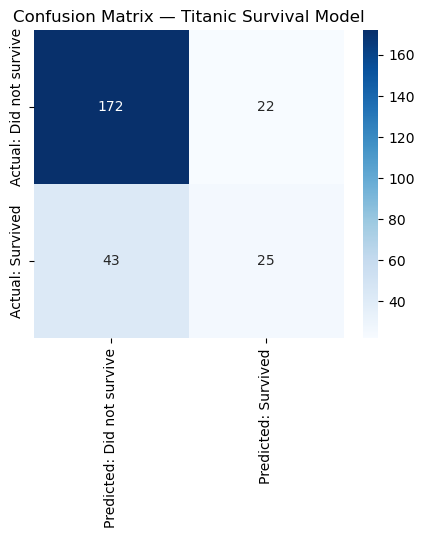

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(X_test)
cm = confusion_matrix(y_test, predictions)

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Did not survive", "Predicted: Survived"],
            yticklabels=["Actual: Did not survive", "Actual: Survived"])
plt.title("Confusion Matrix — Titanic Survival Model")
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Compute precision, recall, and F1 with classification_report, and interpret each</h3>


In [16]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", round(accuracy_score(y_test, predictions), 3))
print()
print(classification_report(y_test, predictions, target_names=["Did not survive", "Survived"]))

Accuracy: 0.752

                 precision    recall  f1-score   support

Did not survive       0.80      0.89      0.84       194
       Survived       0.53      0.37      0.43        68

       accuracy                           0.75       262
      macro avg       0.67      0.63      0.64       262
   weighted avg       0.73      0.75      0.74       262



<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Compare the accuracy number to the class balance from Section 8.0. If accuracy looks high but is close to "always predict the majority class," that is exactly the trap from Section 2 — the precision/recall/F1 numbers above are what confirm the model is actually learning something useful for <i>both</i> classes.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Decide whether precision or recall matters more for this problem, and justify it</h3>


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Your turn:</b> <b>Framing the decision:</b> for a Titanic-style "survived / did not survive" prediction used, say, to prioritize who is checked on first, a <b>False Negative</b> (predicting someone will not survive when they actually would) is arguably less costly than a <b>False Negative in a medical or safety context</b> — but in general, when the cost of <i>missing</i> a positive case is high, <b>recall</b> is the metric to prioritize; when the cost of a <i>false alarm</i> is high, <b>precision</b> is the priority. Fill in your own justification below once you have looked at your own confusion matrix and classif
ication report values.
</div>



<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b><i>
<bold>Precision vs. Recall Decision</bold>

For this problem, **recall is more important** if the model is used in a
safety-oriented situation where missing a potential survivor is costly.

The recall for the Survived class is only 0.37, meaning the model missed
46 out of 73 actual survivors. Therefore, the model should be improved
to identify more actual survivors, even if this causes some additional
false positive predictions</i></b>.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Compute the AUC-ROC and document what it says about the model</h3>


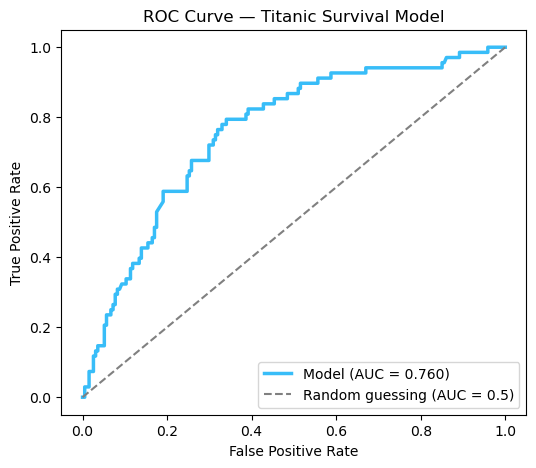

AUC-ROC score: 0.760


In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

probabilities = model.predict_proba(X_test)[:, 1]   # probability of "Survived"
auc_score = roc_auc_score(y_test, probabilities)
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#38BDF8", linewidth=2.5, label=f"Model (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Titanic Survival Model")
plt.legend()
plt.show()

print(f"AUC-ROC score: {auc_score:.3f}")

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> An AUC well above 0.5 (typically 0.8+ here) means the model separates survivors from non-survivors far better than random guessing, across every possible threshold — not just the default 0.5 used above.
</div>


<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <ul>
<li>Always fix <code>random_state=42</code> for the train/test split, for reproducible results.</li>
<li>Report <b>more than one</b> metric — never accuracy alone on a real classification problem.</li>
<li>Always inspect the <b>confusion matrix</b> before trusting a summary metric.</li>
<li>Choose the metric to prioritize (precision vs. recall) <i>before</i> looking at results, based on the real-world cost of each mistake.</li>
<li>Evaluate exclusively on the <b>test set</b>, never the training set.</li>
</ul>
</div>


<a id="section10"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">10. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> <ul>
<li><b>Logistic regression</b> predicts a category by passing a weighted sum through the <b>sigmoid function</b> to get a probability between 0 and 1.</li>
<li><b>Accuracy alone can be dangerously misleading</b> on imbalanced data.</li>
<li>The <b>confusion matrix</b> (TP, FP, FN, TN) is the foundation of every classification metric.</li>
<li><b>Precision</b> asks "how much of what I flagged was right?"; <b>recall</b> asks "how much of the truth did I catch?"; <b>F1</b> balances the two.</li>
<li><b>AUC-ROC</b> compares classifiers across every possible threshold, not just 0.5.</li>
<li>Today's Titanic classifier connects to Day 4, where we compare logistic regression against decision trees, random forests, SVMs, and k-NN on this exact kind of workflow.</li>
</ul>
</div>
